# Dimensionality Reduction Practicum

### 1. Project Background

This project aims to explore and apply feature Engineering and dimensionality reduction techniques on second-hand car sales datasets. The goal is to prepare the dataset for machine learning models by creating informative features and reducing the feature space while retaining essential information.
The second-hand car market is vast, and predicting the price of a used car is a challenging task due to various factors influencing the price. Feature engineering and dimensionality reduction play a crucial role in improving the performance of predictive models by enhancing the quality of input data and reducing noise.

### 2. Load Data & Necessary Libraries

In [79]:
#import all relevant libraries

#analytics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#machine learning
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.manifold import TSNE
import umap.umap_ as umap

In [ ]:
# load the dataset
df=pd.read_csv(r'C:\Users\User\Desktop\advanced_ml\second_hand_cars.csv')
df.head()

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


### 3. Data Pre-processing

In [81]:
#handling missingness & duplicates
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

There is missingness in only 2 features, Variant and Accesories, explore missingness even further by quantifying the missingess..

In [82]:
#how much missingness does each have
total_missing=df.isnull().sum().sort_values(ascending=False)
portion_missing=total_missing/df.isnull().count().sort_values(ascending=False)
missing_df=pd.concat([total_missing,portion_missing],axis=1,keys=['total missing','percent missing'],sort=False)
missing_df.index.name='variable'# set the index name to variable 
missing_df=missing_df[total_missing>0] # only retain those with missing values 
missing_df['percent missing']=missing_df['percent missing'].map(lambda x:x*100) # convert to percentage 
missing_df

,total missing,percent missing
variable,,
Accessories,482,19.28
Variant,262,10.48


Because only a small percent of the training samples are missing, these make them good candidates for imputation. For the variant, I will impute with mode since the data is categorical, but for the Accesories I will opt to replace all missingness with 'None'/'No Accesories'. Why? Because, it could be that the values are not actually missing, the null values could be because that particular car has no accessories like music systems, alloy wheels, sun roofs and etc.

In [83]:
#resolve missingness in variant feature
df['Variant'].fillna(df['Variant'].mode()[0], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_2420\30346414.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Variant'].fillna(df['Variant'].mode()[0], inplace=True)


0             EX
1            RXE
2            RXE
3       Highline
4       Highline
          ...   
2495         RXE
2496          LE
2497         RXE
2498          XL
2499          GT
Name: Variant, Length: 2500, dtype: str

In [84]:
#resolve missingness in accesories feature
df['Accessories'].fillna('No Accesories',inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_2420\4182280200.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Accessories'].fillna('No Accesories',inplace=True)


0                     Music System, Sunroof, Alloy Wheels
1                                           No Accesories
2                                           No Accesories
3                              Music System, Alloy Wheels
4                                       GPS, Music System
                              ...                        
2495                                Music System, Sunroof
2496                                    Music System, GPS
2497                                Alloy Wheels, Sunroof
2498    Leather Seats, Sunroof, Alloy Wheels, Music Sy...
2499                          Leather Seats, Alloy Wheels
Name: Accessories, Length: 2500, dtype: str

In [85]:
#Let's check if we have any missingness
df.isnull().sum()

Company Name                  0
Car Name                      0
Variant                     262
Fuel Type                     0
Tyre Condition                0
Make Year                     0
Owner Type                    0
Registration Number           0
Mileage                       0
Price                         0
Transmission Type             0
Body Color                    0
Service Record                0
Insurance                     0
Registration Certificate      0
Accessories                 482
dtype: int64

In [86]:
#next check for and remove any duplicates
df.drop_duplicates()

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,Toyota,Elantra,RXE,Petrol,New,2015,First,36-450-8953,171112,643581,Automatic,Maroon,Major Service at 105579 km,No Current Insurance,Available,"Music System, Sunroof"
2496,Kia,Sunny,LE,CNG,Needs Replacement,2024,Second,77-453-7512,93545,889661,Manual,White,Major Service at 112605 km,Valid Until [date],Not Available,"Music System, GPS"
2497,Nissan,Sunny,RXE,Diesel,Used,2022,Third,52-366-2337,47285,327520,Automatic (Tiptronic),Gold,Full Service History,Valid Until [date],Not Available,"Alloy Wheels, Sunroof"
2498,Honda,Swift,XL,CNG,Needs Replacement,2019,Second,10-872-5236,67437,348921,Manual,Red,Full Service History,Valid Until [date],Not Available,"Leather Seats, Sunroof, Alloy Wheels, Music Sy..."


Great, now we are working with clean data....after this step, ideally you would go into Exploratory Data Analysis, but for class, we will jump straight into feature engineering.

### 4. Feature Engineering

#### 4.1 Extracting car age from Year of Manufacturer

In [ ]:
#first convert the column to date time data type
from datetime import datetime
df['Make Year']=pd.to_datetime(df['Make Year']) # Convert the 'Make Year' column to datetime format
#set the year
current_year=2024

def car_age(yom):
    current_year=datetime.today().year
    age= current_year-yom.year
    return age

In [43]:
df['Car Age']=df['Make Year'].apply(car_age)

In [ ]:

# Additional Feature Engineering

# Create a new feature called 'Price_per_Mile' to show how much the car costs per unit of mileage and add  +1 to Mileage to avoid division by zero errors
df['Price_per_Mile'] = df['Price'] / (df['Mileage'] + 1)

# Display the first few rows to verify the new feature
print(df[['Price', 'Mileage', 'Price_per_Mile']].head())

    Price  Mileage  Price_per_Mile
0  759107    52798       14.377299
1  505071    43412       11.634096
2  635322    95219        6.672149
3  483152    70370        6.865783
4  712961    85852        8.304439


### 5. Data Encoding

In [91]:
#split data into, categorical, numerical and temporal
num_df=df.select_dtypes(include=[np.number])
cat_df=df.select_dtypes(include=[object])

C:\Users\User\AppData\Local\Temp\ipykernel_2420\4293019885.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df=df.select_dtypes(include=[object])


In [92]:
cat_df.drop('Registration Number',axis=1 ,inplace=True)


In [93]:
#one hot encoding

ohe=OneHotEncoder(sparse_output=False)
ohe_transform=ohe.fit_transform(cat_df)
encoded_df = pd.DataFrame(ohe_transform, columns=ohe.get_feature_names_out(cat_df.columns))
encoded_df.index = cat_df.index
final_df=pd.concat([num_df,encoded_df],axis=1)
final_df.head()

,Mileage,Price,Price_per_Mile,Company Name_Chevrolet,Company Name_Ford,Company Name_Honda,Company Name_Hyundai,Company Name_Kia,Company Name_Maruti Suzuki,Company Name_Nissan,...,"Accessories_Sunroof, Music System","Accessories_Sunroof, Music System, Alloy Wheels","Accessories_Sunroof, Music System, Alloy Wheels, GPS","Accessories_Sunroof, Music System, Alloy Wheels, Leather Seats","Accessories_Sunroof, Music System, GPS","Accessories_Sunroof, Music System, GPS, Alloy Wheels","Accessories_Sunroof, Music System, GPS, Leather Seats","Accessories_Sunroof, Music System, Leather Seats","Accessories_Sunroof, Music System, Leather Seats, GPS",Accessories_nan
0,52798,759107,14.377299,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,43412,505071,11.634096,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,95219,635322,6.672149,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,70370,483152,6.865783,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,85852,712961,8.304439,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [94]:
final_df.shape

(2500, 1110)

See, we now have some very high dimensional data which we are going to reduce using the techniques we learned this week.

In [ ]:

# A Correlation Analysis to identify highly correlated features to reduce multicollinearity

import numpy as np

# Compute correlation matrix for all numeric features in the dataset
corr_matrix = final_df.corr(numeric_only=True)

# Extract only the upper triangle of the correlation matrix (to avoid duplicate pairs since correlation matrix is symmetric)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identify features that have a correlation greater than 0.90 with any other feature
# These features are considered highly redundant
high_corr_features = [
    column for column in upper.columns
    if any(abs(upper[column]) > 0.90)
]

# Print features flagged for removal
print("Highly Correlated Features:", high_corr_features)

# Print how many features will be removed
print("Number of features to remove:", len(high_corr_features))

# Drop the highly correlated features from the dataset
final_df_reduced = final_df.drop(columns=high_corr_features)

# Compare dataset shapes before and after feature removal
print("Original Shape:", final_df.shape)
print("Reduced Shape:", final_df_reduced.shape)


Highly Correlated Features: ['Insurance_Valid Until [date]', 'Registration Certificate_Not Available', 'Accessories_Alloy Wheels, GPS, Leather Seats, Music System', 'Accessories_Music System, Sunroof, GPS, Leather Seats', 'Accessories_Sunroof, GPS, Alloy Wheels, Leather Seats', 'Accessories_Sunroof, Music System, GPS, Leather Seats']
Number of features to remove: 6
Original Shape: (2500, 1110)
Reduced Shape: (2500, 1104)


### 6. Dimensionality Reduction

As you learned in the last session, most of the dimensionality reduction methods are distance based. They have a distance component, so the very first step in dimensionality reduction is feature scaling. Remember also, that all the dimensionality reduction techniques require SCALED & NUMERIC data!

In [96]:
#spilt the data before scaling
X = final_df.drop('Price', axis=1)
y = final_df['Price']
print(X.shape,y.shape)

(2500, 1109) (2500,)


In [97]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2000, 1109) (500, 1109) (2000,) (500,)


In [98]:
#perform standard scaling

scaler=RobustScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Applying PCA

In [99]:
from sklearn.decomposition import PCA, KernelPCA
#pca=PCA(n_components=20)
pca=PCA(0.95)
x_train_pca=pca.fit_transform(X_train)
x_test_pca=pca.transform(X_test)

In [100]:
explained_variance=pca.explained_variance_ratio_
eigen_values=pca.explained_variance_

Text(0.5, 1.0, 'Scree Plot')

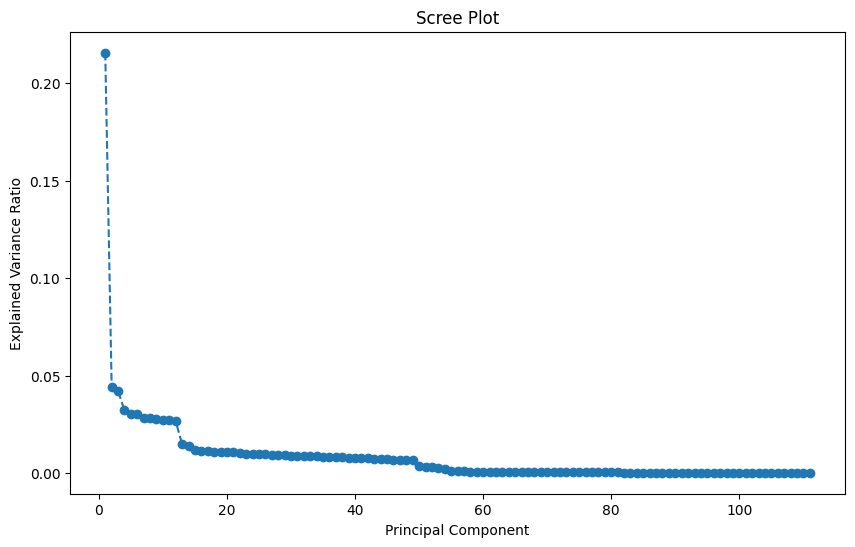

In [101]:
PC_values=np.arange(len(explained_variance))+1
plt.figure(figsize=(10,6)) 
plt.plot(PC_values, explained_variance, marker='o', linestyle='--')
plt.xlabel('Principal Component')       
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')

In [102]:
pca.explained_variance_ratio_*100

array([21.55246855,  4.44812962,  4.22222455,  3.22274958,  3.03736146,
        3.02885327,  2.84528713,  2.83613492,  2.76166213,  2.73507837,
        2.71141288,  2.66044617,  1.50297252,  1.41981222,  1.18379473,
        1.15369283,  1.12995617,  1.11141421,  1.09968904,  1.08254505,
        1.07099108,  1.04577835,  1.01114202,  0.97652706,  0.97363656,
        0.96618123,  0.94691853,  0.92031373,  0.9166645 ,  0.9025547 ,
        0.90028443,  0.88107172,  0.87015421,  0.86691444,  0.84626991,
        0.83029876,  0.82246598,  0.8166224 ,  0.80804   ,  0.80562253,
        0.79637642,  0.77799317,  0.74431554,  0.73754956,  0.71964677,
        0.70628294,  0.69760822,  0.69253363,  0.66753698,  0.39631406,
        0.32605014,  0.31541547,  0.27391368,  0.21888408,  0.10849179,
        0.09775611,  0.09719795,  0.09358747,  0.09339734,  0.09167875,
        0.0876759 ,  0.08570411,  0.08432668,  0.0811643 ,  0.07932434,
        0.0769754 ,  0.07491144,  0.07261885,  0.07002864,  0.06

In [1]:
# Plot the Explained Variance
plt.figure(figsize=(8, 6))

# Create bar plot of explained variance ratio (converted to percentage)
plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_ * 100
)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance Ratio")

# Set x-axis ticks positions
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Rotate x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

NameError: name 'plt' is not defined

Non-Linear Dimensionality Reduction Methods

In [104]:
kpca=KernelPCA(n_components=10)
# kpca=PCA(0.95)
x_train_kpca=kpca.fit_transform(X_train)
x_test_kpca=kpca.transform(X_test)

print(x_test_kpca.shape)
print(x_train_kpca.shape) 


(500, 10)
(2000, 10)


In [105]:
print(type(kpca))


<class 'sklearn.decomposition._kernel_pca.KernelPCA'>


In [ ]:
# Print the eigenvalues from Kernel PCA to show how much variance each principal component captures
# Larger values mean the component is more important
print(kpca.eigenvalues_)

[5025.37926868 1037.16835571  984.49417361  751.44705003  708.22018773
  706.23633601  663.43430235  661.30028627  643.93549979  637.73697789]


In [ ]:

eigen_values = kpca.eigenvalues_

# Convert eigenvalues into explained variance ratio where Each value is divided by the total sum of eigenvalues
# This shows the proportion of total information captured by each component
explained_variance_ratio = eigen_values / eigen_values.sum()

# Print the explained variance ratio for each principal component
print(explained_variance_ratio)

[0.42518228 0.08775171 0.0832951  0.06357768 0.05992039 0.05975254
 0.05613119 0.05595064 0.05448145 0.05395702]


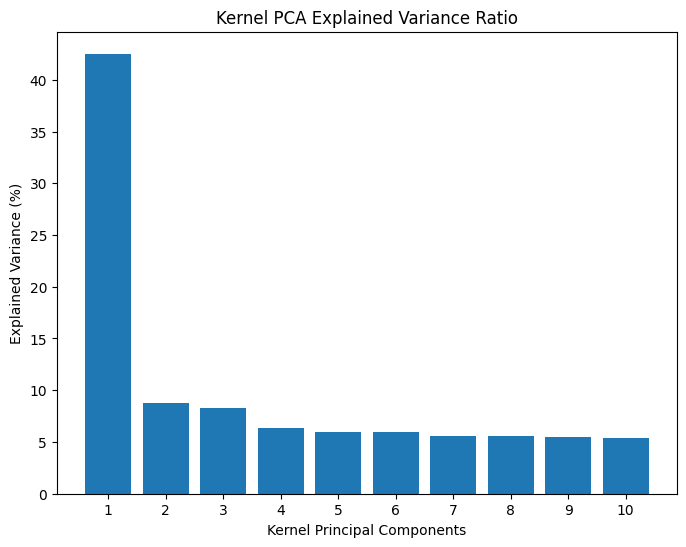

In [108]:
#  Plot the explained Variance
plt.figure(figsize=(8,6))
plt.bar(
    range(1, len(explained_variance_ratio)+1),
    explained_variance_ratio * 100
)

plt.xlabel("Kernel Principal Components")
plt.ylabel("Explained Variance (%)")
plt.title("Kernel PCA Explained Variance Ratio")
plt.xticks(range(1, len(explained_variance_ratio)+1))

plt.show()

Apply TSNE

In [109]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=100, random_state=42)
x_tsne = tsne.fit_transform(X)
print(x_tsne.shape)

(2500, 2)


Apply UMAP

In [110]:
mapper = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = mapper .fit_transform(X)

print(X_umap.shape)

c:\Users\User\Desktop\advanced_ml\adml\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(2500, 2)


### Model training and evaluation

In [111]:
# Model Training and Evaluation

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = []

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    # 'Gradient Boosting': GradientBoostingRegressor(random_state=42)
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200,random_state=42)
}

for name, model in models.items():

    model.fit(x_train_pca, y_train)

    preds = model.predict(x_test_pca)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append([name, r2, mae, rmse])



results_df = pd.DataFrame(
    results,
    columns=['Model', 'R2', 'MAE', 'RMSE']
)

results_df = results_df.sort_values(
    by='R2',
    ascending=False
)

print(results_df)

               Model        R2            MAE           RMSE
2  Gradient Boosting  0.859703   62415.343823   84634.919367
1      Random Forest  0.806143   77349.498100   99486.989240
0  Linear Regression  0.135247  176673.497582  210121.847670


Choose Gradient boosting since it has a higher R2 and a lower MAE

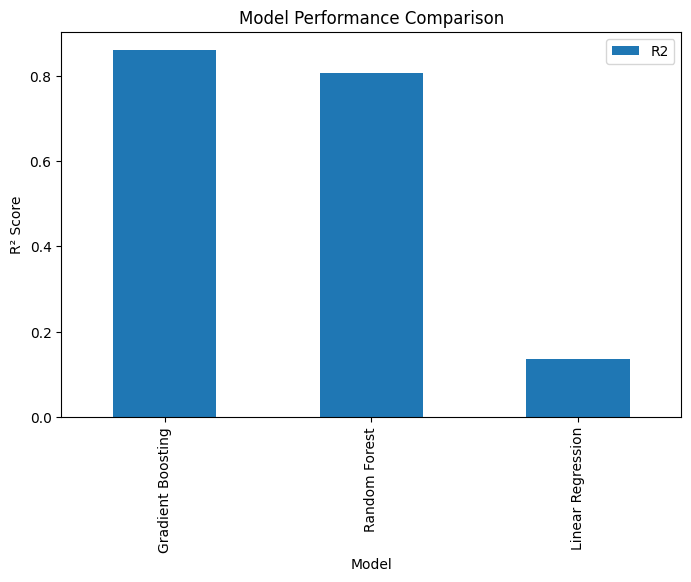

In [112]:
import matplotlib.pyplot as plt

results_df.plot(
    x='Model',
    y='R2',
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Performance Comparison')
plt.ylabel('R² Score')
plt.show()


# Conclusion

## Summary
1. Missing values were identified and imputed.
2. Duplicate records were removed.
3. New features such as Car Age and Price per Mile were created.
4. Categorical variables were encoded using One-Hot Encoding.
5. Numerical features were scaled using RobustScaler.
6. Correlation analysis was used to remove highly correlated variables.
7. PCA successfully reduced dimensionality while retaining 95% of the variance.
8. Kernel PCA, t-SNE and UMAP were applied as non-linear dimensionality reduction techniques.
9. Multiple machine learning models were trained and evaluated.
10. The model with the highest R² and lowest RMSE should be selected as the final model.

## Future Work
- Perform hyperparameter tuning.
- Explore feature selection techniques.
- Compare PCA with Autoencoders and other advanced dimensionality reduction methods.
